# 06 - Define the Commute Risk Metric

Now that we have generated school routes across South Yorkshire and merged them with the STATS19 collision dataset, we aim to identify the risk level of each route. However, defining what makes a route “dangerous” is not straightforward. For example, simply using the number of collisions or casualties would unfairly penalize longer routes, which naturally cover more area and have greater exposure.

Therefore, in this notebook, we explore multiple candidate approaches to fairly assess and compare the relative danger levels of routes, with a particular focus on avoiding arbitrary scoring systems.

In [193]:
# autoreload setup
%load_ext autoreload
%autoreload 2

# imports
import importlib
from util import commute_risk_metrics as crm
importlib.reload(crm)
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [194]:
df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)

In [195]:
df = df.drop(columns='Unnamed: 0')
df = df[(df['casualty_type'] == 0) | (df['casualty_type'] == 1)]
# display(df)
counts = df["accident_index"].value_counts()
print(counts.unique())
average = counts.mean()
print(f"Average count per unique accident_index: {average:.2f}")
route_counts = df.groupby("accident_index")["route_id"].nunique().sort_values(ascending=False)
# print(route_counts.head(10))



[378 243 224 192 108  80  72  54  52  48  40  36  32  31  29  25  24  23
  22  21  20  19  18  17  16  15  14  13  12  11  10   9   8   7   6   5
   4   3   2   1]
Average count per unique accident_index: 9.48


## 1. Build Route-Level Base Metrics

- Total collision count  
- Total casualty count  
- Total severe injuries

These are useful for intuition but **biased toward longer or more-used routes**. Not used in final ranking, shown for reference only.





In [196]:
crm_table = crm.build_commute_risk_metrics(df, filter_col='accident_year', filter_values=[2019, 2020, 2021, 2022, 2023])
# display(crm_table.head(2))

## 2. Per-Kilometre Normalized Metrics

We calculate per-km values for the base metrics defined above. This adjustment accounts for variation in route lengths.

In [197]:
metric_cols = [
  "collision_count", 
  "casualty_count", 
] #  "avg_casualty_severity",  "serious_fatal_casualty_count"
crm_table = crm.add_normalised_metrics(crm_table, metric_cols)
# display(crm_table.head(2))

## 3. Metrics based on Poisson Regression
We use Poisson regression to model expected values based on route length, then compute:
- risk_ratio : ratio of metric value to expected value if all routes were equally risky.
- excess_per_km : metric value - expected value

In [198]:
crm_table = crm.add_poisson_risk_metrics(crm_table, metric_cols)
# display(crm_table.head(2))

## Scaling metric values for ranking and composite score
We will use minmax scaler to avoid biases in composite scores and further analyses.

In [199]:
from sklearn.preprocessing import MinMaxScaler

normalised_cols = [f"{col}_per_km" for col in metric_cols]
poisson_excess_cols = [f"poisson_excess_per_km_{col}" for col in metric_cols]

# Choose columns to scale
metrics = metric_cols + normalised_cols + poisson_excess_cols

scaler = MinMaxScaler()
crm_scaled = crm_table.copy()
crm_scaled[[f"{m}_scaled" for m in metrics]] = scaler.fit_transform(crm_scaled[metrics])
# display(crm_scaled)


5. Add Composite Scores for Percentiles
Here, we create a composite rank each for the normalised metrics (normal counts) and Poisson metric (excess counts), and then create a meta composite percentile rank for both of these.

In [200]:
normalised_cols = [f"{col}_per_km" for col in metric_cols]
poisson_excess_cols = [f"poisson_excess_per_km_{col}" for col in metric_cols]
core_metrics = [f"{m}_scaled" for m in normalised_cols]
poisson_metrics = [f"{m}_scaled" for m in poisson_excess_cols]
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, core_metrics, score_col="core_risk_score")
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, poisson_metrics, score_col="poisson_excess_score")
meta_metrics = ["core_risk_score", "poisson_excess_score"]
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, meta_metrics, score_col="final_composite_score")

# display(crm_scaled)
# print(crm_scaled.sort_values("final_composite_score", ascending=False))


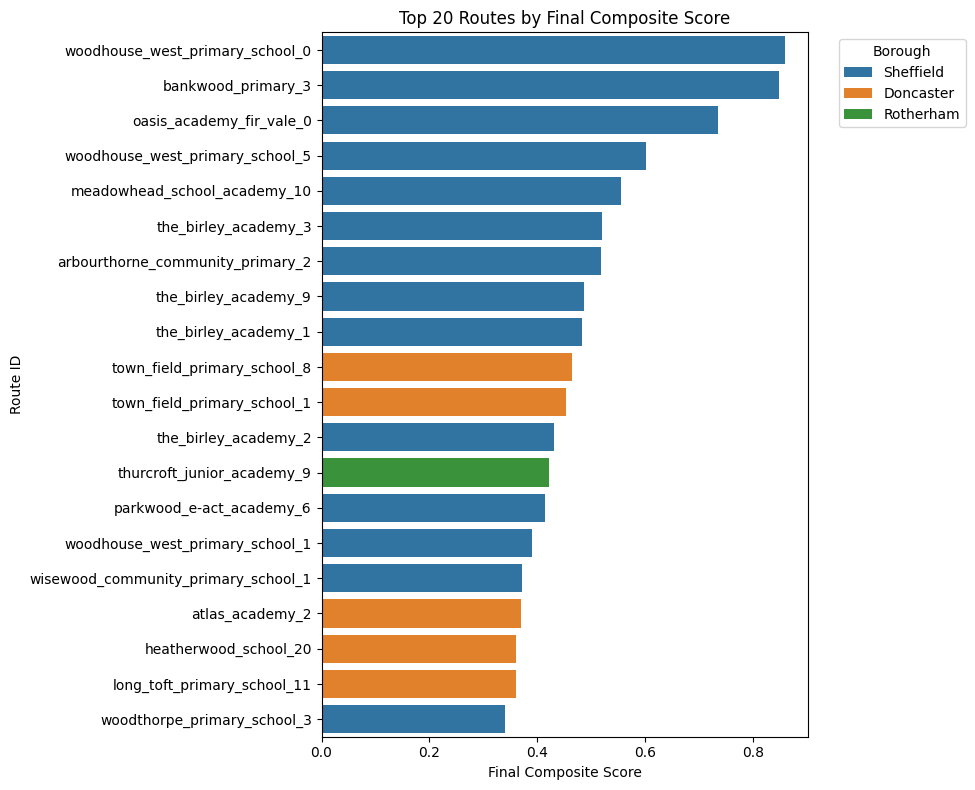

In [164]:
def plot_ranked_routes(df=crm_scaled, metric="final_composite_score", top_n=20):
    import matplotlib.pyplot as plt
    import seaborn as sns

    top_df = df.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_df, x=metric, y="route_id", hue="borough", dodge=False)
    plt.title(f"Top {top_n} Routes by {metric.replace('_', ' ').title()}")
    plt.xlabel(metric.replace('_', ' ').title())
    plt.ylabel("Route ID")
    plt.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_ranked_routes()

In [165]:
def display_top_routes_table(
    df,
    metric="final_composite_score",
    top_n=20,
    group_cols=["borough", "school_name"],
    show_metrics=None
):
    """
    Displays a ranked table of top N routes with their metrics, grouped by borough and school.

    Parameters:
    - df: DataFrame containing route metrics
    - metric: column to rank by
    - top_n: number of top routes to show
    - group_cols: columns to include before metrics (e.g., borough, school_name)
    - show_metrics: list of metrics to display; if None, show all scaled metrics
    """
    import pandas as pd
    from IPython.display import display

    top_df = df.sort_values(metric, ascending=False).head(top_n).copy()
    
    if show_metrics is None:
        show_metrics = [col for col in df.columns]
    
    cols_to_display = group_cols + ["route_id"] + show_metrics
    display(top_df[cols_to_display].reset_index(drop=True))

display_top_routes_table(crm_scaled, metric='casualty_count_per_km', top_n=10)

,borough,school_name,route_id,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,Sheffield,Bankwood Primary,bankwood_primary_3,bankwood_primary_3,Bankwood Primary,Sheffield,0.404,1,3,2.475248,...,7.038545,0.000000,0.250,0.696965,1.000000,0.696965,1.000000,0.848482,0.848482,0.848482
1,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_0,woodhouse_west_primary_school_0,Woodhouse West Primary School,Sheffield,0.885,3,5,3.389831,...,5.262520,0.285714,0.500,0.958843,0.759495,0.958843,0.759495,0.859169,0.859169,0.859169
2,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_5,woodhouse_west_primary_school_5,Woodhouse West Primary School,Sheffield,0.913,2,4,2.190581,...,3.993963,0.142857,0.375,0.615455,0.587711,0.615455,0.587711,0.601583,0.601583,0.601583
3,Sheffield,Oasis Academy Fir Vale,oasis_academy_fir_vale_0,oasis_academy_fir_vale_0,Oasis Academy Fir Vale,Sheffield,0.566,2,2,3.533569,...,3.146371,0.142857,0.125,1.000000,0.472932,1.000000,0.472932,0.736466,0.736466,0.736466
4,Doncaster,Town Field Primary School,town_field_primary_school_1,town_field_primary_school_1,Town Field Primary School,Doncaster,2.723,5,8,1.836210,...,2.550738,0.571429,0.875,0.513986,0.392273,0.513986,0.392273,0.453129,0.453129,0.453129
5,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_1,woodhouse_west_primary_school_1,Woodhouse West Primary School,Sheffield,1.393,2,4,1.435750,...,2.484302,0.142857,0.375,0.399320,0.383277,0.399320,0.383277,0.391298,0.391298,0.391298
6,Sheffield,Bankwood Primary,bankwood_primary_0,bankwood_primary_0,Bankwood Primary,Sheffield,1.083,1,3,0.923361,...,2.382885,0.000000,0.250,0.252604,0.369543,0.252604,0.369543,0.311074,0.311074,0.311074
7,Sheffield,Wisewood Community Primary School,wisewood_community_primary_school_1,wisewood_community_primary_school_1,Wisewood Community Primary School,Sheffield,0.733,1,2,1.364256,...,2.341315,0.000000,0.125,0.378849,0.363914,0.378849,0.363914,0.371381,0.371381,0.371381
8,Doncaster,Town Field Primary School,town_field_primary_school_8,town_field_primary_school_8,Town Field Primary School,Doncaster,1.481,3,4,2.025658,...,2.313680,0.285714,0.375,0.568231,0.360171,0.568231,0.360171,0.464201,0.464201,0.464201
9,Sheffield,Meadowhead School Academy,meadowhead_school_academy_10,meadowhead_school_academy_10,Meadowhead School Academy,Sheffield,1.122,3,3,2.673797,...,2.286599,0.285714,0.250,0.753817,0.356504,0.753817,0.356504,0.555160,0.555160,0.555160


In [168]:
def print_rankings_by_borough(
    df,
    metric="final_composite_score_scaled",
    top_n=5,
    show_metrics=None
):
    """
    Prints a ranking table for each borough, showing top N routes with selected metrics.
    
    Parameters:
    - df: DataFrame with route metrics
    - metric: column to sort by (composite score or base risk metric)
    - top_n: number of top routes per borough
    - show_metrics: optional list of additional metric columns to display;
                    if None, auto-select all *_scaled columns except the base metric
    """
    from IPython.display import display
    boroughs = df["borough"].unique()
    
    if show_metrics is None:
        show_metrics = [
            col for col in df.columns 
        ]

    for borough in sorted(boroughs):
        print(f"\n🔹 Top {top_n} Routes in **{borough}** by {metric.replace('_', ' ').title()}:")
        borough_df = df[df["borough"] == borough].copy()
        top_df = borough_df.sort_values(metric, ascending=False).head(top_n)
        display(top_df.reset_index(drop=True))

# print_rankings_by_borough(crm_scaled, metric='poisson_excess_per_km_collision_count', top_n = 10)
# print(crm_scaled[crm_scaled['school_name']=="Meadstead Primary Academy"])

In [63]:
# crm_table.shape
# crm_table.columns
crm_table.to_csv('../data/routes/commute_risk_metrics_table.csv', index=False)

We see that the baseline is ~6 collisions per km. It is what is expected collision density per km if all routes had the same risk level. Now, we can visualise how the actual collisions look compared to baseline for each route.

##### Plotting Residual Risk

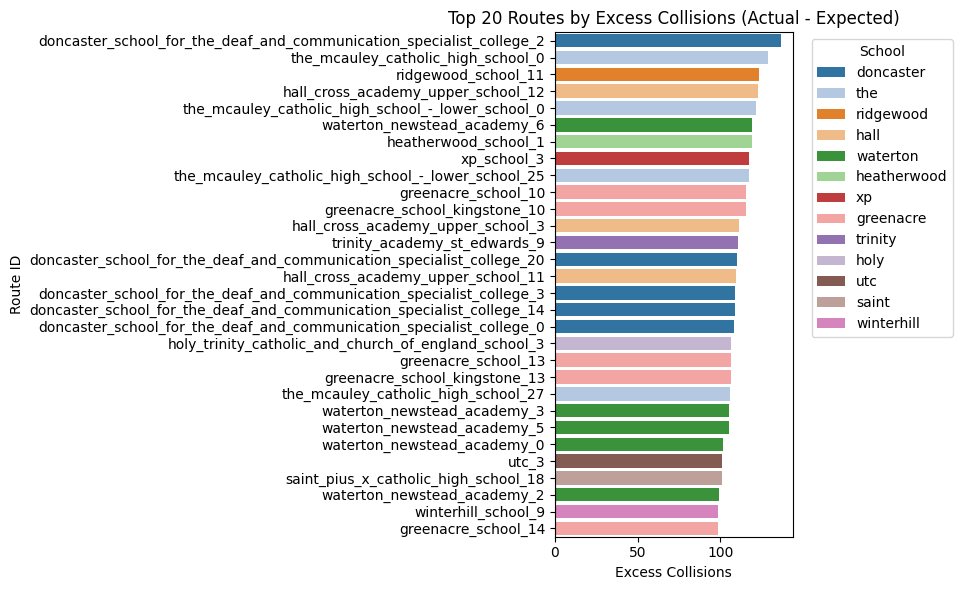

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Extract school name from route_id prefix
# df_model["school_name"] = df_model["route_id"].str.extract(r"(^[^_]+)")

# # Calculate residuals
# df_model["residual"] = df_model["collisions"] - df_model["expected"]

# # Select top 20 by excess collisions
# top_residuals = df_model.sort_values("residual", ascending=False).head(30)

# # Color by school
# school_palette = dict(zip(
#     top_residuals["school_name"].unique(),
#     sns.color_palette("tab20", n_colors=top_residuals["school_name"].nunique())
# ))

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_residuals,
#     x="residual",
#     y="route_id",
#     hue="school_name",
#     dodge=False,
#     palette=school_palette
# )

# plt.axvline(0, color="black", linestyle="--")
# plt.title("Top 20 Routes by Excess Collisions (Actual - Expected)")
# plt.xlabel("Excess Collisions")
# plt.ylabel("Route ID")
# plt.legend(title="School", bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.tight_layout()
# plt.show()



this is interesting, also checked out google maps for doncaster school for the deaf, and its right next to a big highway roundabout.

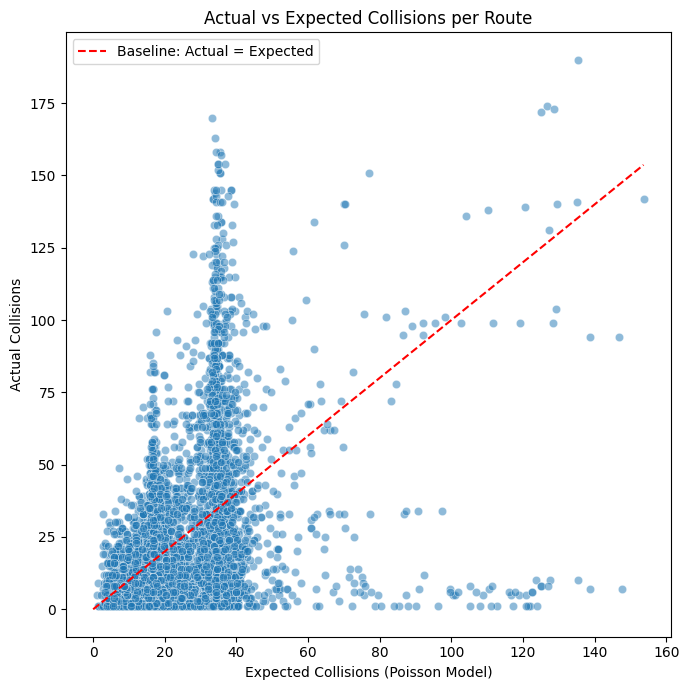

In [ ]:
# plt.figure(figsize=(7, 7))
# sns.scatterplot(data=df_model, x="expected", y="collisions", alpha=0.5)
# plt.plot([0, df_model["expected"].max()], [0, df_model["expected"].max()], color="red", linestyle="--", label="Baseline: Actual = Expected")
# plt.xlabel("Expected Collisions (Poisson Model)")
# plt.ylabel("Actual Collisions")
# plt.title("Actual vs Expected Collisions per Route")
# # plt.xscale("log")
# # plt.yscale("log")
# plt.legend()
# plt.tight_layout()
# plt.show()


<Axes: xlabel='expected', ylabel='collisions'>

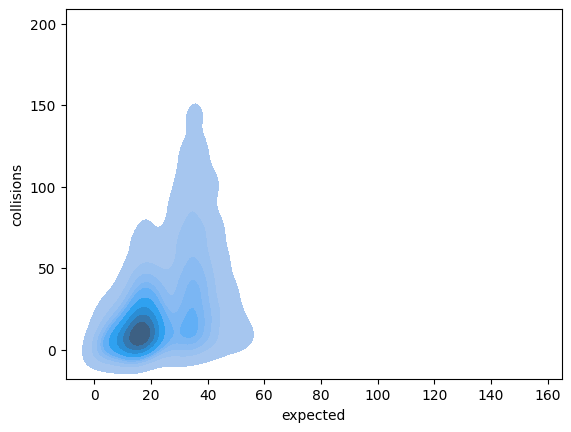

In [ ]:
# sns.kdeplot(data=df_model, x="expected", y="collisions", fill=True, thresh=0.05)

### 1.6. Implementing Machine Learning for Classfication of Routes into Risk level groups

In [169]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
features = [
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]
df = crm_scaled
# Create feature DataFrame
X = df[features].copy()

# Handle any missing values
X = X.fillna(0)

# Apply scaling to normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

In [170]:
# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN (Density-Based Spatial Clustering)
dbscan = DBSCAN(eps=1.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=5)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

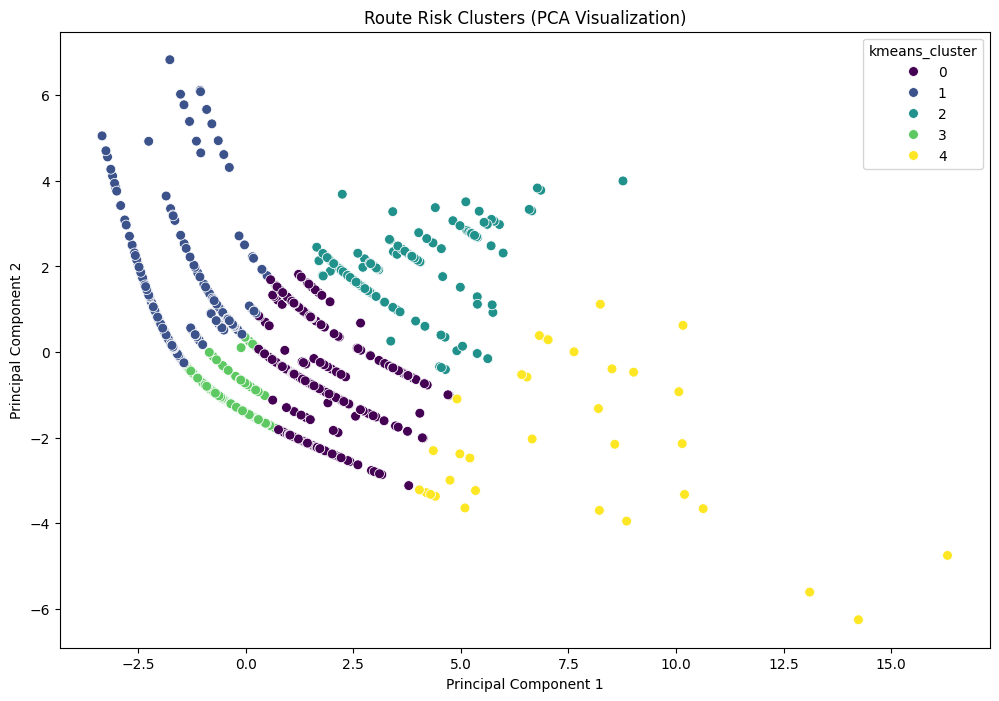

Cluster Statistics:
                 length_km  collision_count  casualty_count  \
kmeans_cluster                                               
4                1.559394         2.787879        3.575758   
2                5.580869         4.514286        4.857143   
0                3.449305         2.195991        2.351893   
3                2.972113         1.037685        1.099596   
1                6.842236         1.317419        1.374194   

                collision_count_per_km  casualty_count_per_km  \
kmeans_cluster                                                  
4                             1.876195               2.507134   
2                             0.830861               0.898688   
0                             0.711563               0.764338   
3                             0.365243               0.387098   
1                             0.206907               0.215818   

                poisson_risk_ratio_collision_count  
kmeans_cluster                     

In [171]:
# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='kmeans_cluster', data=df, palette='viridis', s=50)
plt.title('Route Risk Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('route_risk_clusters.png')
plt.show()

# Analyze cluster characteristics
# Sort clusters from highest to lowest average casualty rate
cluster_stats = df.groupby('kmeans_cluster')[features].mean().sort_values('casualty_count_per_km', ascending=False)
print("Cluster Statistics:\n", cluster_stats)

# Map clusters to readable risk categories
ranked_clusters = cluster_stats.index.tolist()

risk_mapping = {
    ranked_clusters[0]: "Very High Risk",
    ranked_clusters[1]: "High Risk",
    ranked_clusters[2]: "Moderate Risk",
    ranked_clusters[3]: "Low Risk",
    ranked_clusters[4]: "Minimal Risk"
}

df["risk_category"] = df["kmeans_cluster"].map(risk_mapping)


In [172]:
# Determine which cluster represents the highest risk
highest_risk_cluster = cluster_stats.index[0]

# Create risk categories based on clusters
risk_mapping = {
    highest_risk_cluster: 'Very High Risk',
    # Map other clusters based on their statistics
}

# Map clusters to risk categories
df['risk_category'] = df['kmeans_cluster'].map(risk_mapping)

# Get the top 20 highest risk routes for manual review
high_risk_routes = df[df['kmeans_cluster'] == highest_risk_cluster].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
).head(20)

print("\nTop 20 Highest Risk Routes for Manual Review:")
print(high_risk_routes[['route_id', 'school_name', 'length_km', 
                       'collision_count', 'casualty_count', 
                       'collision_count_per_km', 'casualty_count_per_km']])


Top 20 Highest Risk Routes for Manual Review:
                                 route_id                        school_name  \
624                    bankwood_primary_3                   Bankwood Primary   
1476      woodhouse_west_primary_school_0      Woodhouse West Primary School   
1478      woodhouse_west_primary_school_5      Woodhouse West Primary School   
461              oasis_academy_fir_vale_0             Oasis Academy Fir Vale   
634           town_field_primary_school_1          Town Field Primary School   
1477      woodhouse_west_primary_school_1      Woodhouse West Primary School   
621                    bankwood_primary_0                   Bankwood Primary   
1024  wisewood_community_primary_school_1  Wisewood Community Primary School   
160           town_field_primary_school_8          Town Field Primary School   
1141         meadowhead_school_academy_10          Meadowhead School Academy   
215              parkwood_e-act_academy_6             Parkwood E-Act Acad

In [173]:
# Isolation Forest for anomaly detection
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly'] == -1  # -1 indicates anomaly

# Get anomalous routes
anomalous_routes = df[df['is_anomaly']].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
)

print("\nAnomalous High-Risk Routes:")
print(anomalous_routes[['route_id', 'school_name', 'length_km', 
                       'collision_count', 'casualty_count', 
                       'collision_count_per_km', 'casualty_count_per_km']])


Anomalous High-Risk Routes:
                                  route_id  \
624                     bankwood_primary_3   
1476       woodhouse_west_primary_school_0   
1478       woodhouse_west_primary_school_5   
461               oasis_academy_fir_vale_0   
634            town_field_primary_school_1   
...                                    ...   
234   stocksbridge_nursery_infant_school_0   
236   stocksbridge_nursery_infant_school_4   
235   stocksbridge_nursery_infant_school_3   
1417      halfway_nursery_infant_school_13   
1418      halfway_nursery_infant_school_14   

                             school_name  length_km  collision_count  \
624                     Bankwood Primary      0.404                1   
1476       Woodhouse West Primary School      0.885                3   
1478       Woodhouse West Primary School      0.913                2   
461               Oasis Academy Fir Vale      0.566                2   
634            Town Field Primary School      2.723       

In [190]:
# Combine clustering and anomaly detection for final classification
def assign_risk_level(row):
    if row['is_anomaly']:
        return 'Critical Risk'
    elif row['kmeans_cluster'] == highest_risk_cluster:
        return 'Very High Risk'
    # Add more conditions based on your clusters
    else:
        return 'Normal Risk'

df['final_risk_level'] = df.apply(assign_risk_level, axis=1)

# Final list of routes for manual review
final_review_routes = df[df['final_risk_level'].isin(['Critical Risk', 'Very High Risk'])].sort_values(
    by=['final_risk_level', 'casualty_count_per_km'], 
    ascending=[False, False]
)

# print("\nFinal Routes for Manual Review:")
# display(final_review_routes[['route_id', 'school_name', 'length_km', 
#                          'collision_count', 'casualty_count', 
#                          'final_risk_level']].head(30))

C:\Users\REALME\AppData\Local\Temp\ipykernel_6920\2243880339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_risk_level', data=df, palette='rocket')


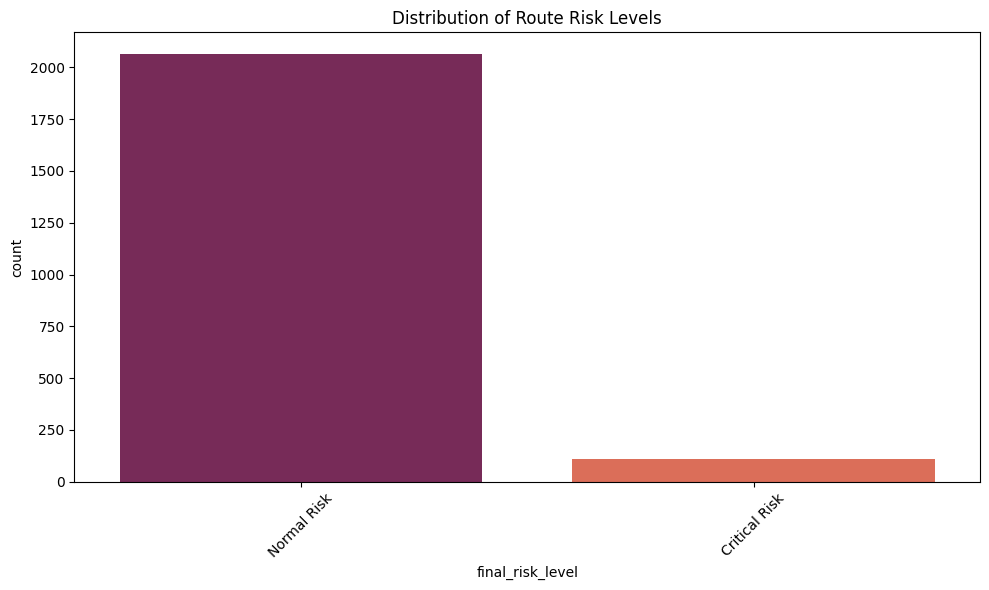

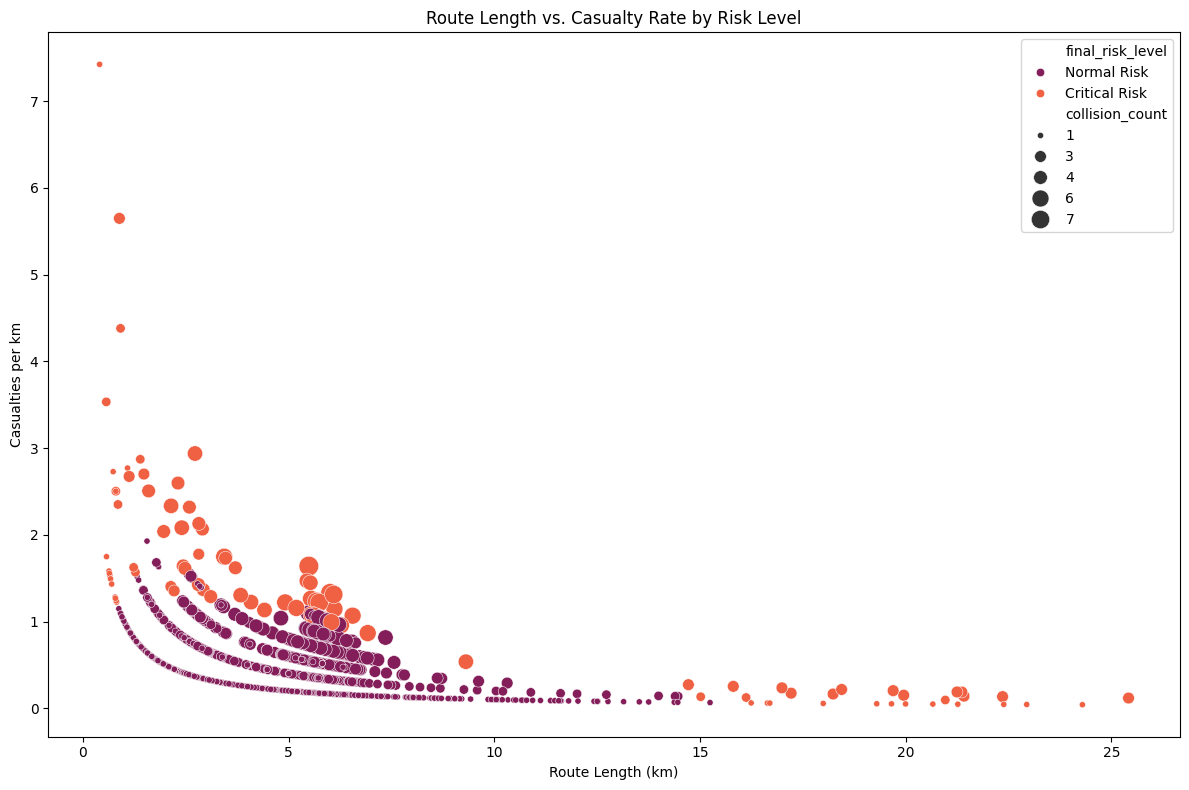

In [175]:
# Risk level distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='final_risk_level', data=df, palette='rocket')
plt.title('Distribution of Route Risk Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('risk_level_distribution.png')

# Length vs Risk scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='length_km', y='casualty_count_per_km', 
                hue='final_risk_level', size='collision_count',
                sizes=(20, 200), data=df, palette='rocket')
plt.title('Route Length vs. Casualty Rate by Risk Level')
plt.xlabel('Route Length (km)')
plt.ylabel('Casualties per km')
plt.tight_layout()
plt.savefig('length_vs_risk.png')

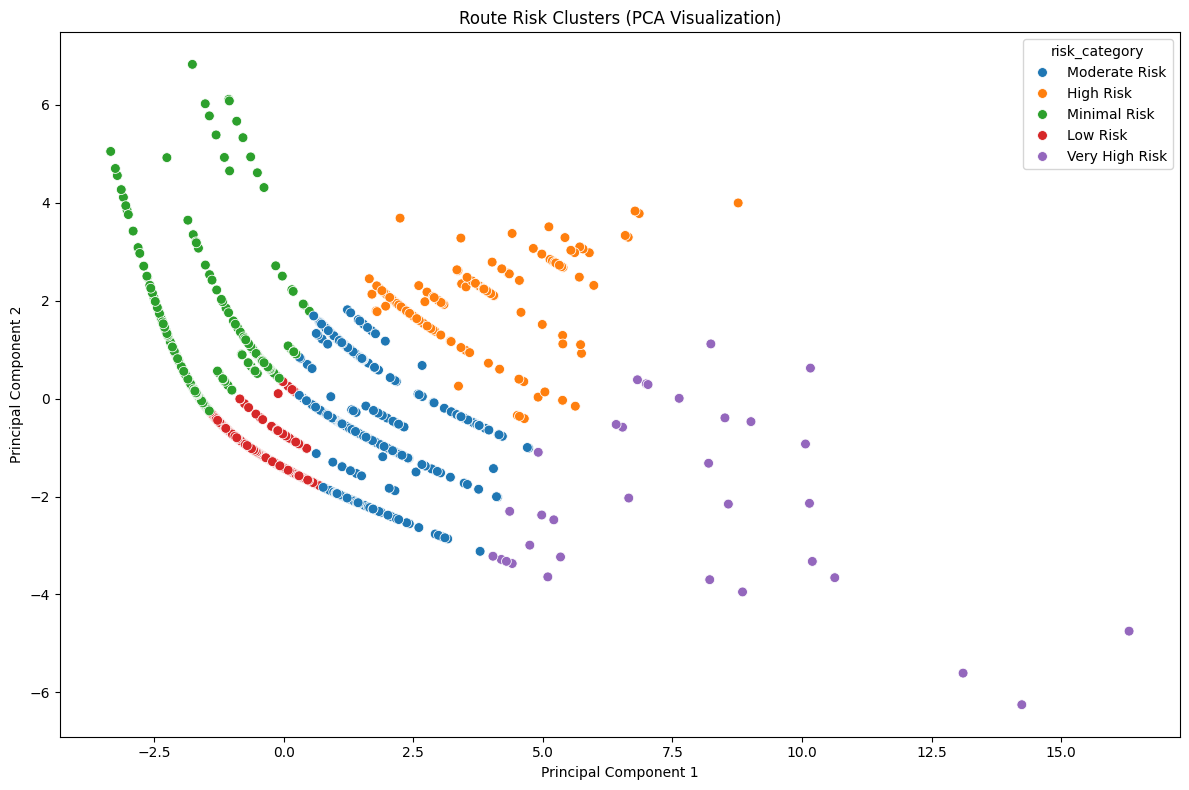

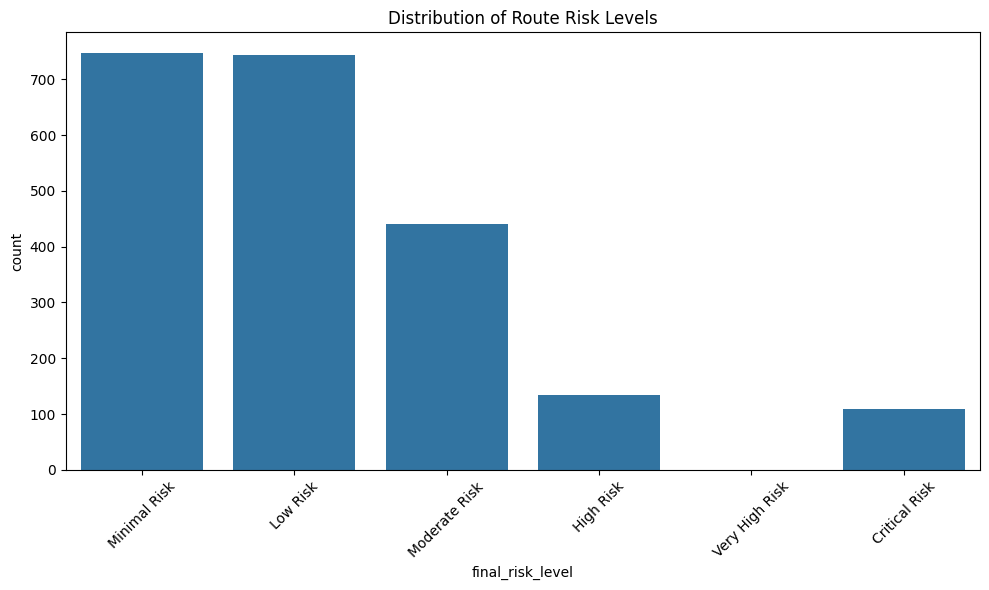

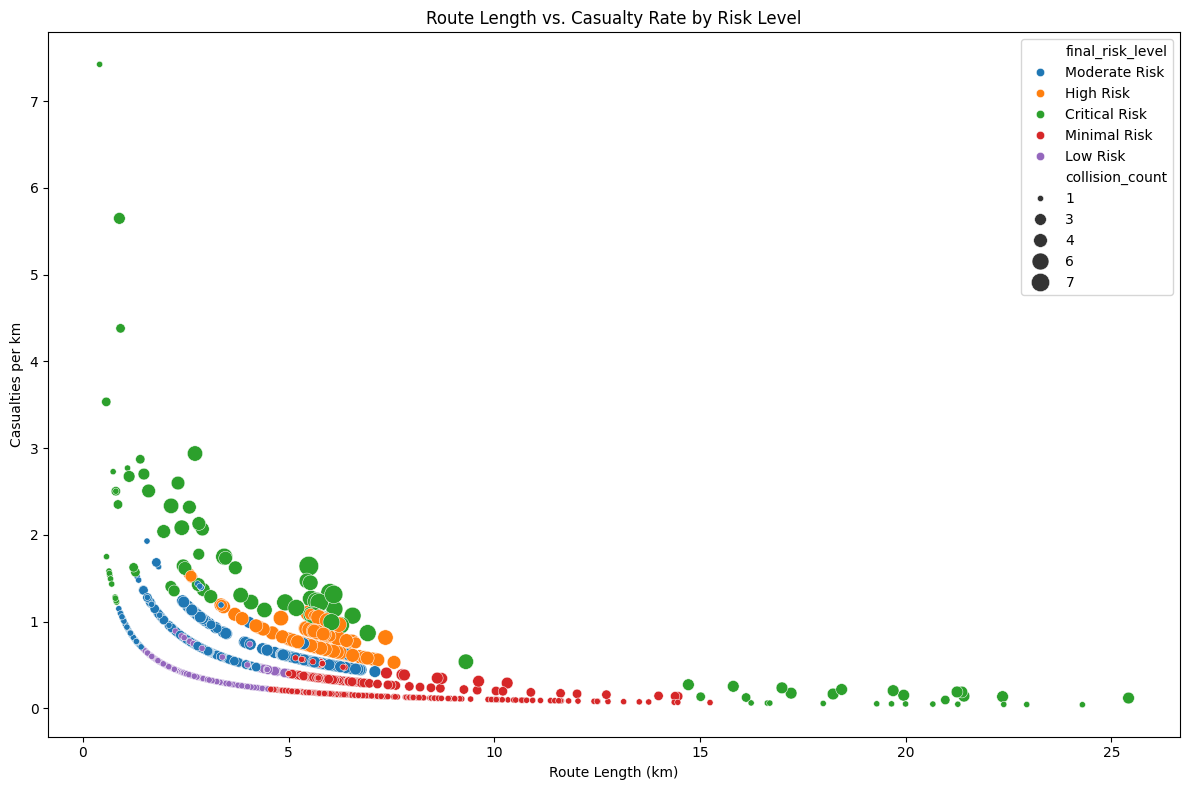

In [176]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Example placeholder DataFrame (to be replaced with real one)
# df = pd.read_csv("your_input.csv")

# ---- Configuration ----
features = [
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]
# ---- Preprocessing ----
X = df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- Clustering ----
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Optional: DBSCAN and Hierarchical
df['dbscan_cluster'] = DBSCAN(eps=1.0, min_samples=5).fit_predict(X_scaled)
df['hierarchical_cluster'] = AgglomerativeClustering(n_clusters=5).fit_predict(X_scaled)

# ---- PCA for Visualization ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'], df['pca_2'] = X_pca[:, 0], X_pca[:, 1]

# ---- Analyze Cluster Stats ----
cluster_stats = df.groupby('kmeans_cluster')[features].mean().sort_values('casualty_count_per_km', ascending=False)
ranked_clusters = cluster_stats.index.tolist()

# ---- Map Clusters to Risk Categories ----
risk_mapping = {
    ranked_clusters[0]: "Very High Risk",
    ranked_clusters[1]: "High Risk",
    ranked_clusters[2]: "Moderate Risk",
    ranked_clusters[3]: "Low Risk",
    ranked_clusters[4]: "Minimal Risk"
}
df["risk_category"] = df["kmeans_cluster"].map(risk_mapping)

# ---- Anomaly Detection ----
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly'] == -1

# ---- Final Risk Level ----
df["final_risk_level"] = df.apply(
    lambda row: "Critical Risk" if row['is_anomaly'] else row['risk_category'],
    axis=1
)

# ---- Final Review Table ----
final_review_routes = df[df['final_risk_level'].isin(['Critical Risk', 'Very High Risk'])]\
    .sort_values(by=['final_risk_level', 'casualty_count_per_km'], ascending=[False, False])\
    .head(30)

# ---- Visualizations ----

# PCA Cluster Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='risk_category', data=df, s=50)
plt.title('Route Risk Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# Risk Level Distribution
plt.figure(figsize=(10, 6))
risk_order = ["Minimal Risk", "Low Risk", "Moderate Risk", "High Risk", "Very High Risk", "Critical Risk"]
sns.countplot(x='final_risk_level', data=df, order=risk_order)
plt.title('Distribution of Route Risk Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Length vs. Casualty per km Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='length_km', y='casualty_count_per_km',
    hue='final_risk_level', size='collision_count',
    sizes=(20, 200), data=df
)
plt.title('Route Length vs. Casualty Rate by Risk Level')
plt.xlabel('Route Length (km)')
plt.ylabel('Casualties per km')
plt.tight_layout()
plt.show()

# ---- Display Top Routes ----
display(name="Top 30 Routes for Manual Review", dataframe=final_review_routes[[
    'route_id', 'school_name', 'borough', 'length_km',
    'collision_count', 'casualty_count',
    'collision_count_per_km', 'casualty_count_per_km',
    'risk_category', 'is_anomaly', 'final_risk_level'
]])


In [152]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
components = pd.DataFrame(pca.components_, columns=features, index=["PC1", "PC2"])
print(components.T)

                                         PC1       PC2
length_km                          -0.079269  0.749277
collision_count                     0.408410  0.396374
casualty_count                      0.401485  0.413121
collision_count_per_km              0.488280 -0.216150
casualty_count_per_km               0.434617 -0.131764
poisson_risk_ratio_collision_count  0.488280 -0.216150


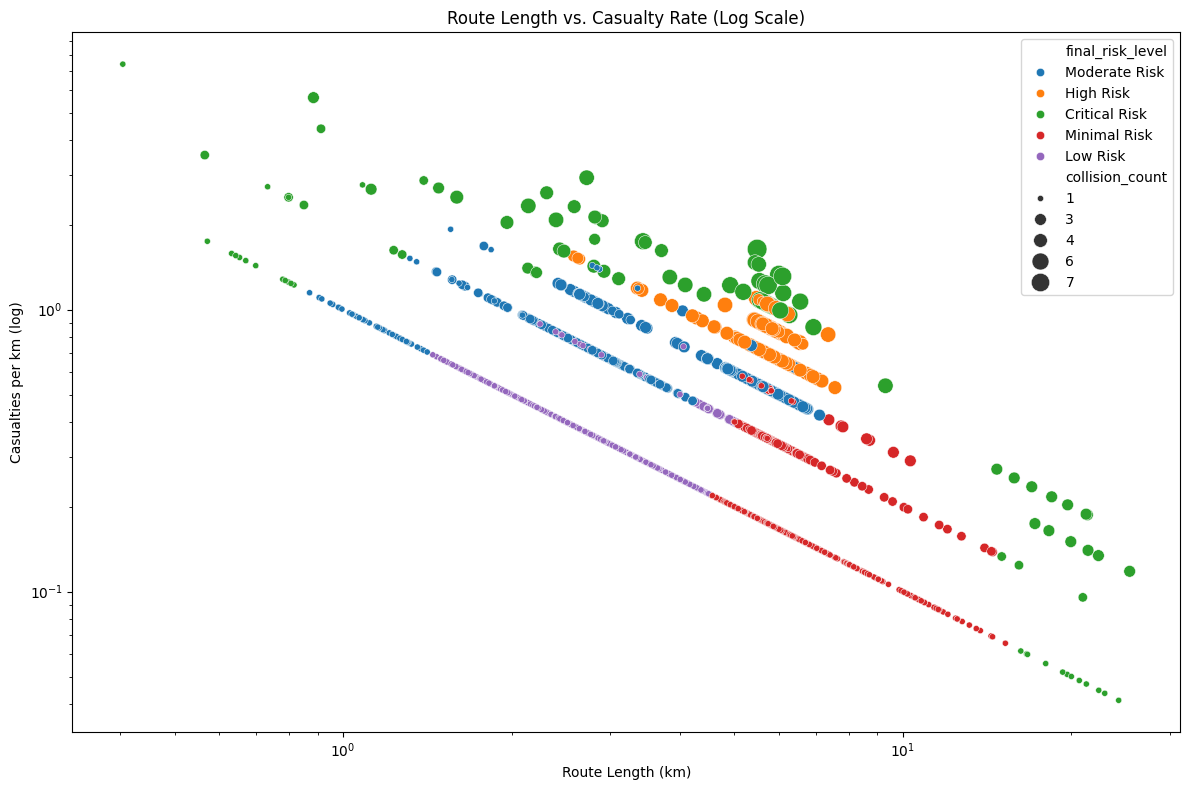

In [178]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='length_km', 
    y='casualty_count_per_km',
    hue='final_risk_level',
    size='collision_count',
    sizes=(20, 200),
    data=df,
)
plt.xscale("log")  # Optional — only if x is also skewed
plt.yscale("log")  # Recommended
plt.title("Route Length vs. Casualty Rate (Log Scale)")
plt.xlabel("Route Length (km)")
plt.ylabel("Casualties per km (log)")
plt.tight_layout()
plt.show()


In [179]:
risk_level_stats = df.groupby("final_risk_level")[[
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]].agg(['mean', 'median', 'max', 'count'])

# Flatten multi-level column headers
risk_level_stats.columns = ['_'.join(col).strip() for col in risk_level_stats.columns.values]
risk_level_stats = risk_level_stats.reset_index()

# Display it
# from IPython.display import display
display(risk_level_stats)


,final_risk_level,length_km_mean,length_km_median,length_km_max,length_km_count,collision_count_mean,collision_count_median,collision_count_max,collision_count_count,casualty_count_mean,...,collision_count_per_km_max,collision_count_per_km_count,casualty_count_per_km_mean,casualty_count_per_km_median,casualty_count_per_km_max,casualty_count_per_km_count,poisson_risk_ratio_collision_count_mean,poisson_risk_ratio_collision_count_median,poisson_risk_ratio_collision_count_max,poisson_risk_ratio_collision_count_count
0,Critical Risk,7.492440,5.527,25.415,109,3.559633,3.0,8,109,4.055046,...,3.533569,109,1.327232,1.232177,7.425743,109,3.009195,2.991585,9.739388,109
1,High Risk,5.655704,5.716,7.561,135,4.170370,4.0,5,135,4.459259,...,1.192606,135,0.808564,0.763942,1.550388,135,2.077222,1.966290,3.287116,135
2,Low Risk,2.972113,2.837,5.076,743,1.037685,1.0,2,743,1.099596,...,0.691563,743,0.387098,0.359712,0.889680,743,1.006701,0.983320,1.906118,743
3,Minimal Risk,6.371833,5.844,15.242,747,1.290495,1.0,3,747,1.340027,...,0.406725,747,0.219349,0.178955,0.580833,747,0.580536,0.491923,1.121033,747
4,Moderate Risk,3.491220,2.929,7.096,441,2.208617,2.0,3,441,2.367347,...,1.364256,441,0.754590,0.713521,1.928021,441,1.931735,1.887840,3.760227,441


In [182]:
# Sort and get top 10 per final_risk_level by casualty_count_per_km
ranked_routes = df.sort_values(by=["final_risk_level", "casualty_count_per_km"], ascending=[True, False])
top_n_per_level = ranked_routes.groupby("final_risk_level").head(10).copy()

# Select columns to display
ranking_cols = [
    'final_risk_level', 'route_id', 'school_name', 'borough',
    'length_km', 'collision_count', 'casualty_count',
    'collision_count_per_km', 'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]

# Display result
df0 = top_n_per_level[ranking_cols]
display(df0)
df0.to_csv('rankings.csv')


,final_risk_level,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count
624,Critical Risk,bankwood_primary_3,Bankwood Primary,Sheffield,0.404,1,3,2.475248,7.425743,6.822393
1476,Critical Risk,woodhouse_west_primary_school_0,Woodhouse West Primary School,Sheffield,0.885,3,5,3.389831,5.649718,9.343209
1478,Critical Risk,woodhouse_west_primary_school_5,Woodhouse West Primary School,Sheffield,0.913,2,4,2.190581,4.381161,6.037780
461,Critical Risk,oasis_academy_fir_vale_0,Oasis Academy Fir Vale,Sheffield,0.566,2,2,3.533569,3.533569,9.739388
634,Critical Risk,town_field_primary_school_1,Town Field Primary School,Doncaster,2.723,5,8,1.836210,2.937936,5.061048
1477,Critical Risk,woodhouse_west_primary_school_1,Woodhouse West Primary School,Sheffield,1.393,2,4,1.435750,2.871500,3.957282
621,Critical Risk,bankwood_primary_0,Bankwood Primary,Sheffield,1.083,1,3,0.923361,2.770083,2.545011
1024,Critical Risk,wisewood_community_primary_school_1,Wisewood Community Primary School,Sheffield,0.733,1,2,1.364256,2.728513,3.760227
160,Critical Risk,town_field_primary_school_8,Town Field Primary School,Doncaster,1.481,3,4,2.025658,2.700878,5.583214
1141,Critical Risk,meadowhead_school_academy_10,Meadowhead School Academy,Sheffield,1.122,3,3,2.673797,2.673797,7.369644


In [185]:
import os

# Sort and rank
ranked_routes = df.sort_values(by=["final_risk_level", "casualty_count_per_km"], ascending=[True, False])
top_n = ranked_routes.groupby(["borough", "final_risk_level"]).head(10).copy()

# Columns to show (reorder for clarity)
cols = [
    'route_id', 'school_name', 'borough',
    'length_km', 'collision_count', 'casualty_count',
    'collision_count_per_km', 'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]

# Output path
output_path = "ranked_route_risk_report.txt"

# Custom sort order for risk levels
risk_order = [
    "Critical Risk", "Very High Risk", "High Risk",
    "Moderate Risk", "Low Risk", "Minimal Risk"
]

# Sort by risk → borough
top_n['risk_sort'] = top_n['final_risk_level'].apply(lambda x: risk_order.index(x) if x in risk_order else 999)
top_n = top_n.sort_values(by=["risk_sort", "borough", "casualty_count_per_km"], ascending=[True, True, False])

# Write to file
with open(output_path, "w", encoding="utf-8") as f:
    for risk in risk_order:
        df_risk = top_n[top_n['final_risk_level'] == risk]
        if df_risk.empty:
            continue

        f.write(f"\n{'='*80}\n🏷️  RISK LEVEL: {risk.upper()}\n{'='*80}\n\n")
        
        for borough in sorted(df_risk['borough'].unique()):
            df_b = df_risk[df_risk['borough'] == borough][cols]
            f.write(f"\n--- Borough: {borough} ---\n")
            f.write(df_b.to_string(index=False))
            f.write("\n\n")

print(f"Saved nicely formatted rankings to: {output_path}")



Saved nicely formatted rankings to: ranked_route_risk_report.txt


In [189]:
# %pip install XlsxWriter

import pandas as pd

# Sort and rank
ranked_routes = df.sort_values(by=["final_risk_level", "casualty_count_per_km"], ascending=[True, False])
top_n = ranked_routes.groupby(["borough", "final_risk_level"]).head(10).copy()

# Columns to show
cols = [
    'final_risk_level', 'route_id', 'school_name', 'borough',
    'length_km', 'collision_count', 'casualty_count',
    'collision_count_per_km', 'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]

top_n = top_n[cols]

# Output Excel file
excel_path = "ranked_routes_by_borough.xlsx"

# Write each borough to a separate sheet
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    for borough in sorted(top_n['borough'].unique()):
        df_b = top_n[top_n['borough'] == borough]
        sheet_name = borough.replace(" ", "_")[:31]  # Excel sheet name limit
        df_b.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved Excel report with one sheet per borough to: {excel_path}")



Saved Excel report with one sheet per borough to: ranked_routes_by_borough.xlsx
